In [1]:
import sys
print(sys.version)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]


In [2]:
import pandas as pd

print("Pandas funcionando!")
print(pd.__version__)

Pandas funcionando!
3.0.5


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Todas as bibliotecas estão funcionando!")

Todas as bibliotecas estão funcionando!


In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/ecommerce_orders_raw.csv")

df.head()

,order_id,order_date,customer_id,customer_name,country,region,product_category,product_name,quantity,unit_price,discount,shipping_cost,payment_method,unit_cost,revenue,total_cost,profit,profit_margin
0,ORD003313,2024-07-12,C00972,Customer 972,United Kingdom,Europe,Accessories,Backpack,3,69.99,0.00,24.07,PayPal,35.0,209.97,129.07,80.90,0.3853
1,ORD009079,2025-06-29,C01440,Customer 1440,Germany,Europe,Electronics,Bluetooth Speaker,3,59.99,0.15,8.66,Debit Card,32.0,152.97,104.66,48.31,0.3158
2,ORD005618,2024-11-30,C01366,Customer 1366,United States,North America,Electronics,Wireless Headphones,3,79.99,0.00,3.49,Credit Card,45.0,239.97,138.49,101.48,0.4229
3,ORD001148,2024-02-16,C01180,Customer 1180,France,Europe,Home,Office Chair,3,199.99,0.00,12.46,PayPal,120.0,599.97,372.46,227.51,0.3792
4,ORD008768,2024-02-25,C00969,Customer 969,United States,North America,Home,Coffee Maker,1,89.99,0.20,6.93,Credit Card,48.0,71.99,54.93,17.06,0.2370


In [6]:
df.shape

(10025, 18)

In [7]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'country',
       'region', 'product_category', 'product_name', 'quantity', 'unit_price',
       'discount', 'shipping_cost', 'payment_method', 'unit_cost', 'revenue',
       'total_cost', 'profit', 'profit_margin'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10025 entries, 0 to 10024
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10025 non-null  str    
 1   order_date        10025 non-null  str    
 2   customer_id       10025 non-null  str    
 3   customer_name     9974 non-null   str    
 4   country           10025 non-null  str    
 5   region            10025 non-null  str    
 6   product_category  10025 non-null  str    
 7   product_name      10025 non-null  str    
 8   quantity          10025 non-null  int64  
 9   unit_price        10025 non-null  float64
 10  discount          10025 non-null  float64
 11  shipping_cost     10025 non-null  float64
 12  payment_method    9995 non-null   str    
 13  unit_cost         10025 non-null  float64
 14  revenue           10025 non-null  float64
 15  total_cost        10025 non-null  float64
 16  profit            10025 non-null  float64
 17  prof

In [9]:
df.isnull().sum()

order_id             0
order_date           0
customer_id          0
customer_name       51
country              0
region               0
product_category     0
product_name         0
quantity             0
unit_price           0
discount             0
shipping_cost        0
payment_method      30
unit_cost            0
revenue              0
total_cost           0
profit               0
profit_margin        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(25)

In [11]:
df["product_category"].value_counts()

product_category
Electronics    2534
Accessories    2498
Home           2489
Fitness        2464
electronics      40
Name: count, dtype: int64

In [12]:
df["discount"].describe()

count    10025.000000
mean         0.073606
std          0.087892
min          0.000000
25%          0.000000
50%          0.050000
75%          0.150000
max          1.250000
Name: discount, dtype: float64

In [13]:
(df["discount"] < 0).sum(), (df["discount"] > 0.20).sum()

(np.int64(0), np.int64(15))

In [14]:
df["order_date"].min(), df["order_date"].max()

('2024-01-01', '2025-12-30')

In [15]:
df_clean = df.copy()

print("Cópia criada!")

Cópia criada!


In [16]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Linhas após remover duplicados: {len(df_clean):,}")

Linhas após remover duplicados: 10,000


In [17]:
df_clean["product_category"] = df_clean["product_category"].replace(
    "electronics",
    "Electronics"
)

print(df_clean["product_category"].value_counts())

product_category
Electronics    2566
Accessories    2489
Home           2487
Fitness        2458
Name: count, dtype: int64


In [18]:
invalid_discount = df_clean["discount"] > 0.20

df_clean.loc[invalid_discount, "discount"] = np.nan

print(f"Invalid discounts replaced with NaN: {invalid_discount.sum()}")

Invalid discounts replaced with NaN: 15


In [19]:
df_clean[df_clean["customer_name"].isna()][
    ["customer_id", "customer_name"]
].head(10)

,customer_id,customer_name
208,C01294,NaN
586,C00928,NaN
636,C01234,NaN
851,C00264,NaN
927,C01893,NaN
1291,C01224,NaN
1663,C01363,NaN
1703,C01938,NaN
1797,C01507,NaN
1861,C01867,NaN


In [20]:
customer_name_lookup = (
    df_clean.dropna(subset=["customer_name"])
    .drop_duplicates("customer_id")
    .set_index("customer_id")["customer_name"]
)

print(f"Customers with a known name: {len(customer_name_lookup):,}")

Customers with a known name: 1,987


In [21]:
df_clean["customer_name"] = df_clean["customer_name"].fillna(
    df_clean["customer_id"].map(customer_name_lookup)
)

print(
    f"Missing customer names remaining: "
    f"{df_clean['customer_name'].isna().sum()}"
)

Missing customer names remaining: 0


In [22]:
df_clean["payment_method"].value_counts(dropna=False)

payment_method
Debit Card       2589
Bank Transfer    2502
Credit Card      2488
PayPal           2391
NaN                30
Name: count, dtype: int64

In [23]:
df_clean["payment_method"] = df_clean["payment_method"].fillna("Unknown")

print(
    f"Missing payment methods remaining: "
    f"{df_clean['payment_method'].isna().sum()}"
)

Missing payment methods remaining: 0


In [24]:
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"])

print(df_clean["order_date"].dtype)

datetime64[us]


In [25]:
df_clean[["quantity", "unit_price", "discount", "shipping_cost",
          "unit_cost", "revenue", "total_cost", "profit",
          "profit_margin"]].describe()

,quantity,unit_price,discount,shipping_cost,unit_cost,revenue,total_cost,profit,profit_margin
count,10000.000000,10000.000000,9985.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.372000,73.065100,0.071848,14.014202,39.339700,161.451283,107.739002,53.712214,0.259998
std,1.392699,49.745994,0.075244,6.336906,30.237327,160.478503,100.365351,63.068171,0.192585
min,1.000000,21.990000,0.000000,3.000000,9.000000,17.590000,12.080000,-16.310000,-0.927000
25%,1.000000,29.990000,0.000000,8.570000,12.000000,59.380000,42.577500,12.190000,0.204700
50%,2.000000,69.990000,0.050000,13.980000,35.000000,104.970000,70.345000,32.875000,0.307450
75%,3.000000,99.990000,0.150000,19.472500,55.000000,199.990000,137.562500,70.722500,0.384100
max,5.000000,199.990000,0.200000,25.000000,120.000000,999.950000,624.630000,396.910000,0.579500


In [26]:
loss_orders = (df_clean["profit"] < 0).sum()

print(f"Orders with negative profit: {loss_orders}")

Orders with negative profit: 916


In [27]:
calculated_margin = df_clean["profit"] / df_clean["revenue"]

margin_difference = (
    df_clean["profit_margin"] - calculated_margin
).abs()

print(f"Maximum margin difference: {margin_difference.max()}")

Maximum margin difference: 0.00023138146674239746


In [28]:
checks = {
    "Invalid quantity": (df_clean["quantity"] <= 0).sum(),
    "Invalid unit price": (df_clean["unit_price"] <= 0).sum(),
    "Invalid unit cost": (df_clean["unit_cost"] <= 0).sum(),
    "Invalid revenue": (df_clean["revenue"] <= 0).sum(),
}

checks

{'Invalid quantity': np.int64(0),
 'Invalid unit price': np.int64(0),
 'Invalid unit cost': np.int64(0),
 'Invalid revenue': np.int64(0)}

In [29]:
df_clean.to_csv(
    "../data/processed/ecommerce_orders_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")
print(f"Rows: {len(df_clean):,}")
print(f"Columns: {len(df_clean.columns)}")

Clean dataset saved successfully!
Rows: 10,000
Columns: 18


In [31]:
total_revenue = df_clean["revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $1,614,512.83


In [32]:
total_profit = df_clean["profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $537,122.14


In [33]:
overall_profit_margin = total_profit / total_revenue

print(f"Overall Profit Margin: {overall_profit_margin:.2%}")

Overall Profit Margin: 33.27%


In [34]:
average_order_value = total_revenue / len(df_clean)

print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $161.45


In [35]:
revenue_by_category = (
    df_clean.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

product_category
Home           648072.15
Electronics    443146.68
Fitness        324472.37
Accessories    198821.63
Name: revenue, dtype: float64

In [36]:
profit_by_category = (
    df_clean.groupby("product_category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_category

product_category
Home           219897.66
Electronics    140856.75
Fitness        111979.62
Accessories     64388.11
Name: profit, dtype: float64

In [37]:
category_performance = (
    df_clean.groupby("product_category")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "count")
    )
)

category_performance["profit_margin"] = (
    category_performance["profit"]
    / category_performance["revenue"]
)

category_performance = category_performance.sort_values(
    "profit",
    ascending=False
)

category_performance

,revenue,profit,orders,profit_margin
product_category,,,,
Home,648072.15,219897.66,2487,0.339310
Electronics,443146.68,140856.75,2566,0.317856
Fitness,324472.37,111979.62,2458,0.345113
Accessories,198821.63,64388.11,2489,0.323849


In [38]:
top_products = (
    df_clean.groupby("product_name")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "count")
    )
    .sort_values("profit", ascending=False)
    .head(10)
)

top_products

,revenue,profit,orders
product_name,,,
Office Chair,264146.46,85118.75,600
Air Purifier,216075.12,79346.95,657
Smart Watch,187204.73,62602.13,638
Fitness Tracker,143855.21,49428.49,633
Coffee Maker,121873.02,43227.34,616
Dumbbell Set,105242.52,36987.28,602
Wireless Headphones,115861.14,36296.24,641
Backpack,93194.73,34284.23,615
Bluetooth Speaker,78634.52,24875.59,609


In [39]:
bottom_products = (
    df_clean.groupby("product_name")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "count")
    )
    .sort_values("profit", ascending=True)
    .head(10)
)

bottom_products

,revenue,profit,orders
product_name,,,
Water Bottle,31679.47,8769.70,658
Travel Mug,33737.36,8782.10,646
Resistance Bands,33981.02,10815.45,605
Desk Lamp,47641.93,12672.37,620
Laptop Sleeve,41270.13,12997.41,580
Yoga Mat,42270.42,14997.06,630
USB-C Hub,57845.05,15921.05,650
Bluetooth Speaker,78634.52,24875.59,609
Backpack,93194.73,34284.23,615


In [40]:
loss_by_product = (
    df_clean[df_clean["profit"] < 0]
    .groupby("product_name")
    .agg(
        loss_orders=("order_id", "count"),
        total_loss=("profit", "sum")
    )
    .sort_values("total_loss")
)

loss_by_product

,loss_orders,total_loss
product_name,,
Water Bottle,159,-1022.13
Travel Mug,155,-1007.63
Resistance Bands,124,-782.14
Laptop Sleeve,107,-550.30
Yoga Mat,105,-501.30
Desk Lamp,106,-496.33
USB-C Hub,89,-457.26
Bluetooth Speaker,31,-116.20
Wireless Headphones,18,-31.59


In [41]:
discount_analysis = (
    df_clean.assign(
        order_status=df_clean["profit"].apply(
            lambda x: "Loss" if x < 0 else "Profitable"
        )
    )
    .groupby("order_status")
    .agg(
        orders=("order_id", "count"),
        avg_discount=("discount", "mean"),
        avg_profit=("profit", "mean")
    )
)

discount_analysis

,orders,avg_discount,avg_profit
order_status,,,
Loss,916,0.102842,-5.457424
Profitable,9084,0.068721,59.678681


In [42]:
monthly_revenue = (
    df_clean
    .groupby(df_clean["order_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue

order_date
2024-01    65919.57
2024-02    59897.52
2024-03    66044.11
2024-04    69446.16
2024-05    73871.71
2024-06    60687.99
2024-07    68501.30
2024-08    66801.08
2024-09    64913.27
2024-10    67878.66
2024-11    67060.10
2024-12    72323.43
2025-01    69096.80
2025-02    62405.37
2025-03    70568.14
2025-04    68082.01
2025-05    71436.42
2025-06    63032.09
2025-07    66924.29
2025-08    66323.96
2025-09    64428.75
2025-10    71459.29
2025-11    68327.73
2025-12    69083.08
Freq: M, Name: revenue, dtype: float64

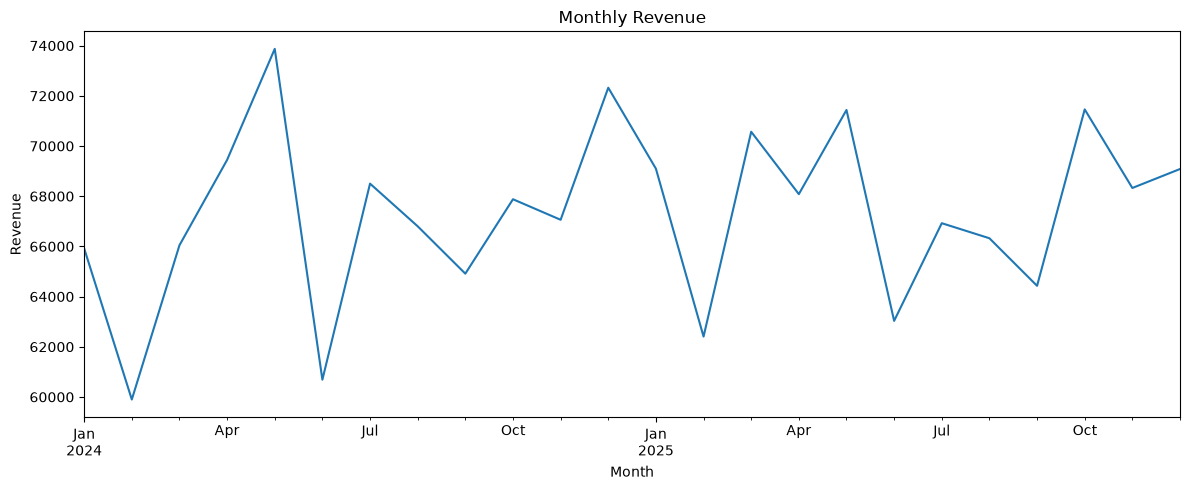

In [48]:
monthly_revenue.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Revenue"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()

plt.savefig("../visualizations/monthly_revenue.png", dpi=300)
plt.show()

In [44]:
revenue_by_region = (
    df_clean.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_region

region
Europe           810434.86
North America    523700.35
Oceania          280377.62
Name: revenue, dtype: float64

In [45]:
region_performance = (
    df_clean.groupby("region")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "count")
    )
)

region_performance["profit_margin"] = (
    region_performance["profit"] / region_performance["revenue"]
)

region_performance.sort_values("profit", ascending=False)

,revenue,profit,orders,profit_margin
region,,,,
Europe,810434.86,269102.83,5047,0.332047
North America,523700.35,173216.18,3251,0.330754
Oceania,280377.62,94803.13,1702,0.338127


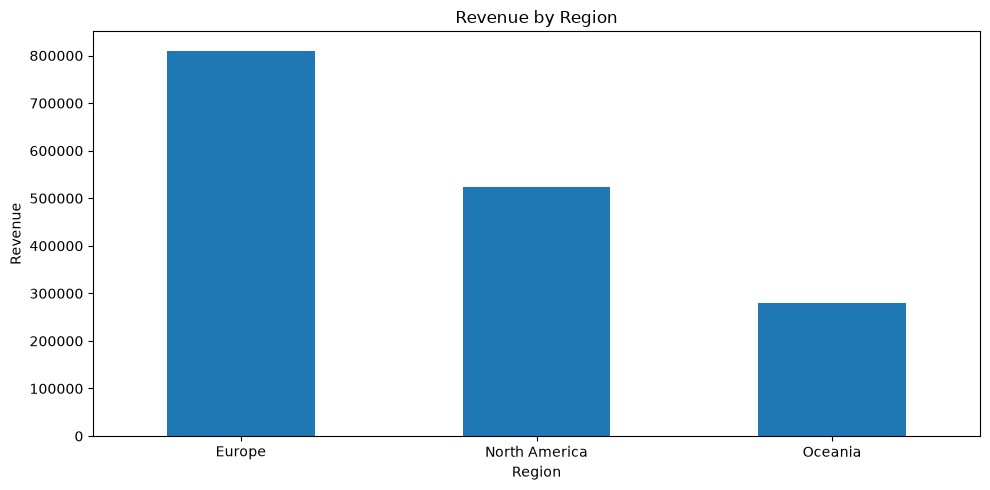

In [46]:
revenue_by_region.plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Region"
)

plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

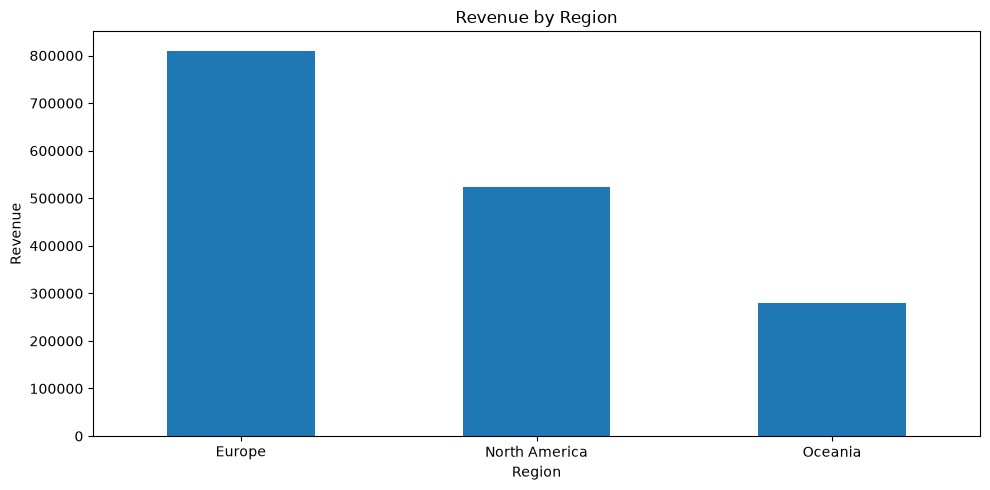

In [49]:
revenue_by_region.plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue by Region"
)

plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/revenue_by_region.png", dpi=300)
plt.show()

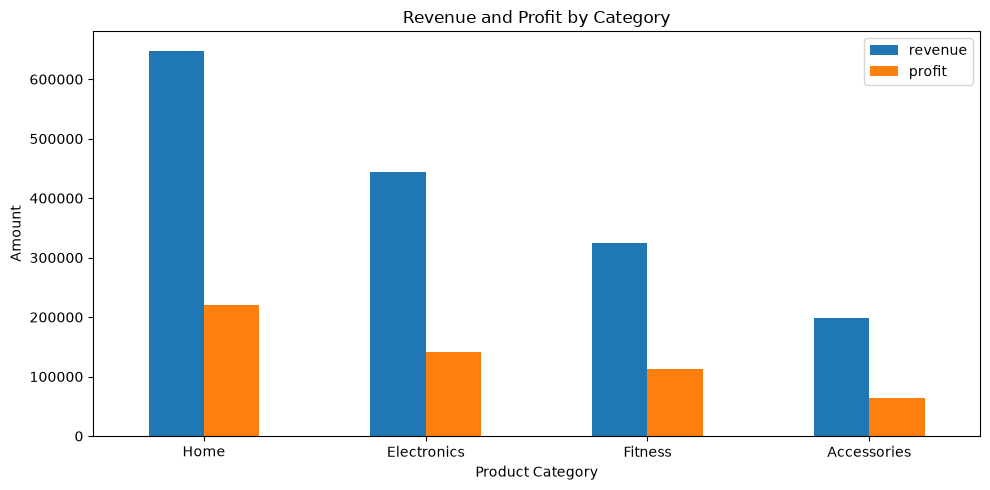

In [50]:
category_performance[["revenue", "profit"]].plot(
    kind="bar",
    figsize=(10, 5),
    title="Revenue and Profit by Category"
)

plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/category_revenue_profit.png", dpi=300)
plt.show()